# Lithuanian Macroeconomic Time Series Pipeline

This notebook executes the full macro indicator pipeline for Lithuania:
- deterministic endpoint resolution (World Bank + Eurostat + IMF)
- normalized long-format indicator data
- raw and indexed overlay charts for each indicator
- acceptance and gap diagnostics


In [1]:
import sys
from pathlib import Path

from IPython.display import Image, Markdown, display

country_code = globals().get('country_code', 'LT')

current_dir = Path.cwd()
search_roots = [current_dir, *current_dir.parents]
module_path = next(
    (
        p
        for p in search_roots
        if (p / "macro_indicator_core.py").exists() and (p / "macro_indicator_pipeline.py").exists()
    ),
    None,
)
if module_path is None:
    module_path = next((p for p in search_roots if (p / "macro_indicator_pipeline.py").exists()), None)
if module_path is None:
    raise FileNotFoundError("macro_indicator_pipeline.py not found in current or parent directories.")

if str(module_path.resolve()) not in sys.path:
    sys.path.insert(0, str(module_path.resolve()))

from macro_indicator_pipeline import (
    get_pipeline_root,
    load_indicator_plot_glossary,
    resolve_indicator_plot_glossary_path,
    run,
    stream_resolved_sources,
)

root = get_pipeline_root()
project_subdir = Path('bs2026_student_projects') / 'Arturas_Sotnicenko'
outdir = root / project_subdir / 'outputs'


In [2]:
results = run(country_code=country_code, outdir=str(outdir), include_analysis=True)

indicator_index = results['indicator_index']
coverage = results['coverage']
missing_queue = results['missing_queue']
series_registry = results['series_registry']
resolved_registry = results['resolved_registry']
normalized_df = results['normalized_df']
fetch_status = results['fetch_status']
chart_manifest = results['chart_manifest']
coverage_gaps = results['coverage_gaps']
acceptance_checks = results['acceptance_checks']

stream = stream_resolved_sources(country_code=country_code, coverage=coverage)
endpoint_status = stream['endpoint_status_df']


In [3]:
glossary_path = resolve_indicator_plot_glossary_path(
    root=root,
    current_dir=current_dir,
    project_subdir=str(project_subdir),
)
if glossary_path is not None:
    chart_type_glossary, indicator_glossary = load_indicator_plot_glossary(glossary_path)
else:
    chart_type_glossary, indicator_glossary = {}, {}

print(f'Country code: {country_code}')
print(f'Output directory: {outdir.resolve()}')
if glossary_path is not None:
    print(f'Glossary loaded: {glossary_path}')
else:
    print('Glossary loaded: none (INDICATOR_PLOT_GLOSSARY.md not found)')


Country code: LT
Output directory: /workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs
Glossary loaded: /workspaces/da-ai/INDICATOR_PLOT_GLOSSARY.md


In [4]:
print('Coverage status counts:')
display(coverage['status'].value_counts().rename_axis('status').reset_index(name='count'))

print('Resolved endpoints in coverage:')
# display(
#     coverage[coverage['status'] == 'resolved'][
#         ['indicator_id', 'source_id', 'series_label', 'mapping_quality', 'resolved_url']
#     ].sort_values(['indicator_id', 'source_id'])
# )

print('Resolved registry diagnostics:')
# display(
#     resolved_registry[
#         [
#             'indicator_id',
#             'source_id',
#             'endpoint_status',
#             'resolution_reason',
#             'http_status',
#             'resolved_url',
#         ]
#     ].sort_values(['indicator_id', 'source_id'])
# )


Coverage status counts:


,status,count
0,missing_source,24
1,known_but_missing_params,19
2,resolved,17


Resolved endpoints in coverage:
Resolved registry diagnostics:


In [5]:
print('Mapping quality summary:')
# display(
#     series_registry.groupby(['indicator_id', 'mapping_quality'])
#     .size()
#     .rename('count')
#     .reset_index()
#     .sort_values(['indicator_id', 'mapping_quality'])
# )

print('Fetch status:')
# display(fetch_status.sort_values(['indicator_id', 'source_id']))

print('Coverage gaps and proxy caveats:')
# display(coverage_gaps.sort_values(['indicator_id', 'source_id', 'gap_type']))


Mapping quality summary:
Fetch status:
Coverage gaps and proxy caveats:


In [6]:
print('Normalized indicator dataset (head):')
# display(normalized_df.head(20))

print('Plot-ready source count by indicator:')
# display(
#     normalized_df.groupby('indicator_id')['source_id']
#     .nunique()
#     .rename('plot_ready_sources')
#     .reset_index()
#     .sort_values('indicator_id')
# )

print('Acceptance checks:')
# display(acceptance_checks)


Normalized indicator dataset (head):
Plot-ready source count by indicator:
Acceptance checks:


## gdp_current_usd

,chart_type,status,base_year,file_path,note
5,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
3,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,Rendered in canonical USD so IMF NGDPD (billio...
4,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


**overlay_index**

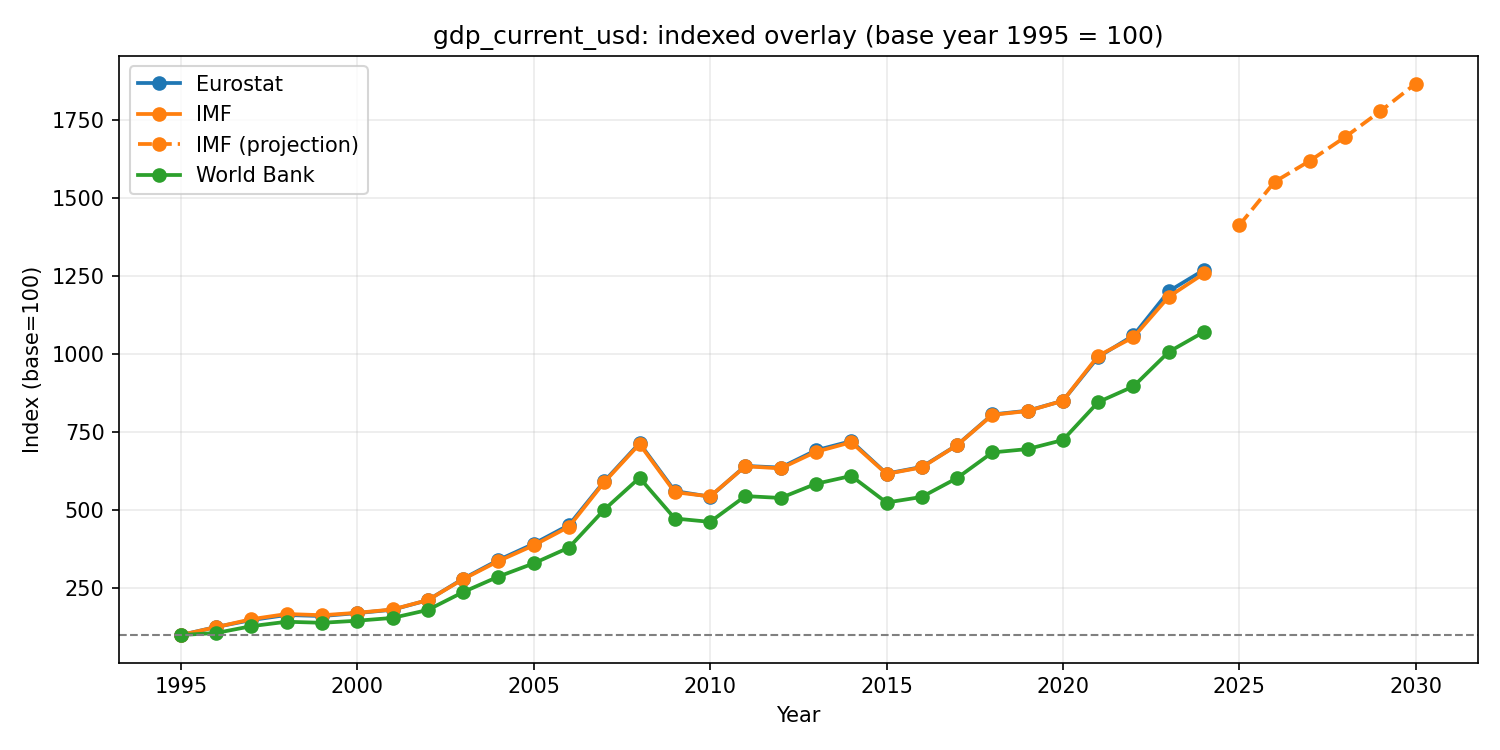

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NY.GDP.MKTP.CD`) | `USD` | `USD` | `value_canonical = value_raw` | Exact mapping |
| IMF (`NGDPD`) | source-defined | `USD` | `value_canonical = value_raw * 1e9` | WEO-backed; future years are projection-flagged |
| Eurostat (`nama_10_gdp`, `CP_MEUR`) | million EUR | `USD` | `value_canonical = value_raw * 1e6 * usd_per_eur(year)` | Uses annual USD/EUR conversion from Eurostat FX series |

**raw**

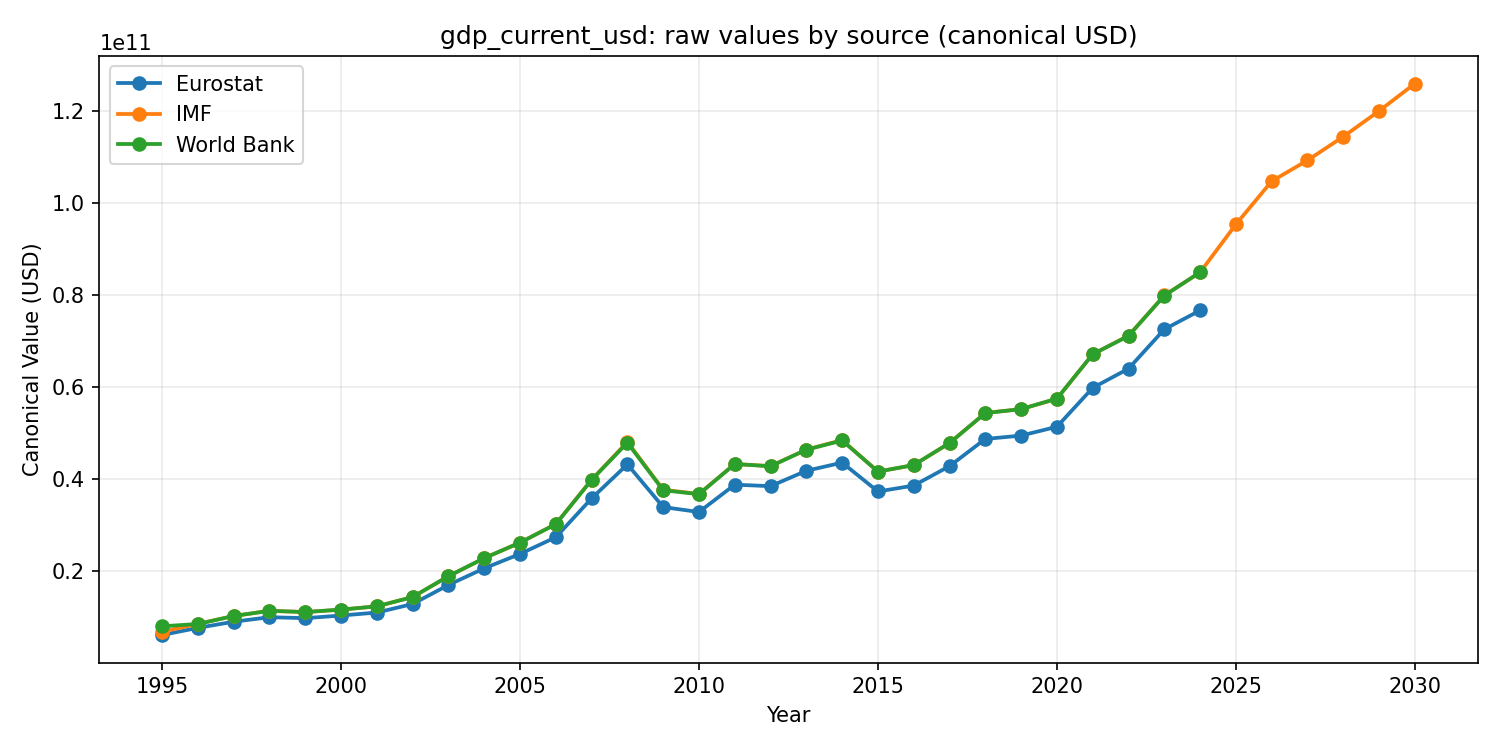

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` which is rendered in canonical USD to avoid mixed-scale flattening.

**raw_harmonized**

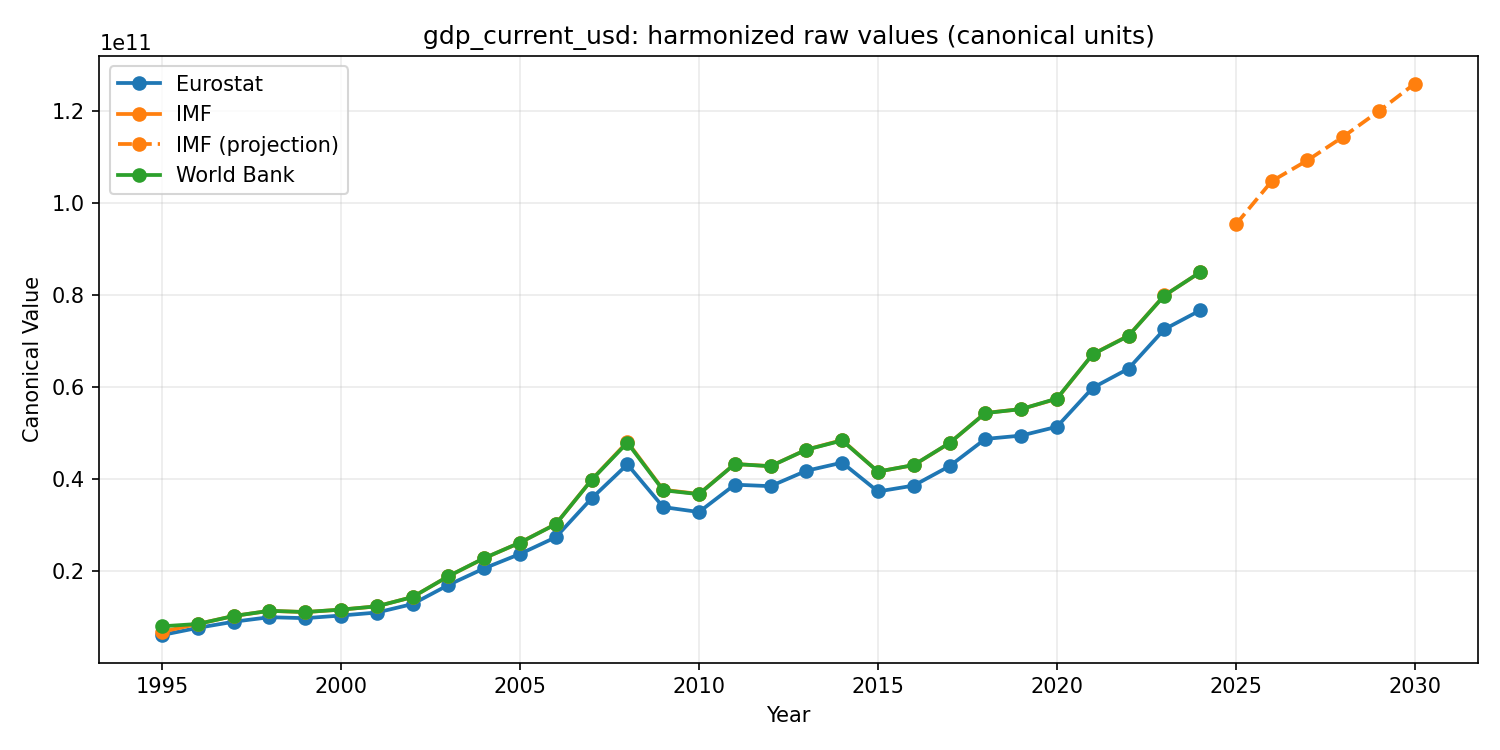

_Glossary:_ canonical-unit values for comparable cross-source analysis.

## inflation_cpi_yoy

,chart_type,status,base_year,file_path,note
8,overlay_index,ok,1996.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
6,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
7,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


**overlay_index**

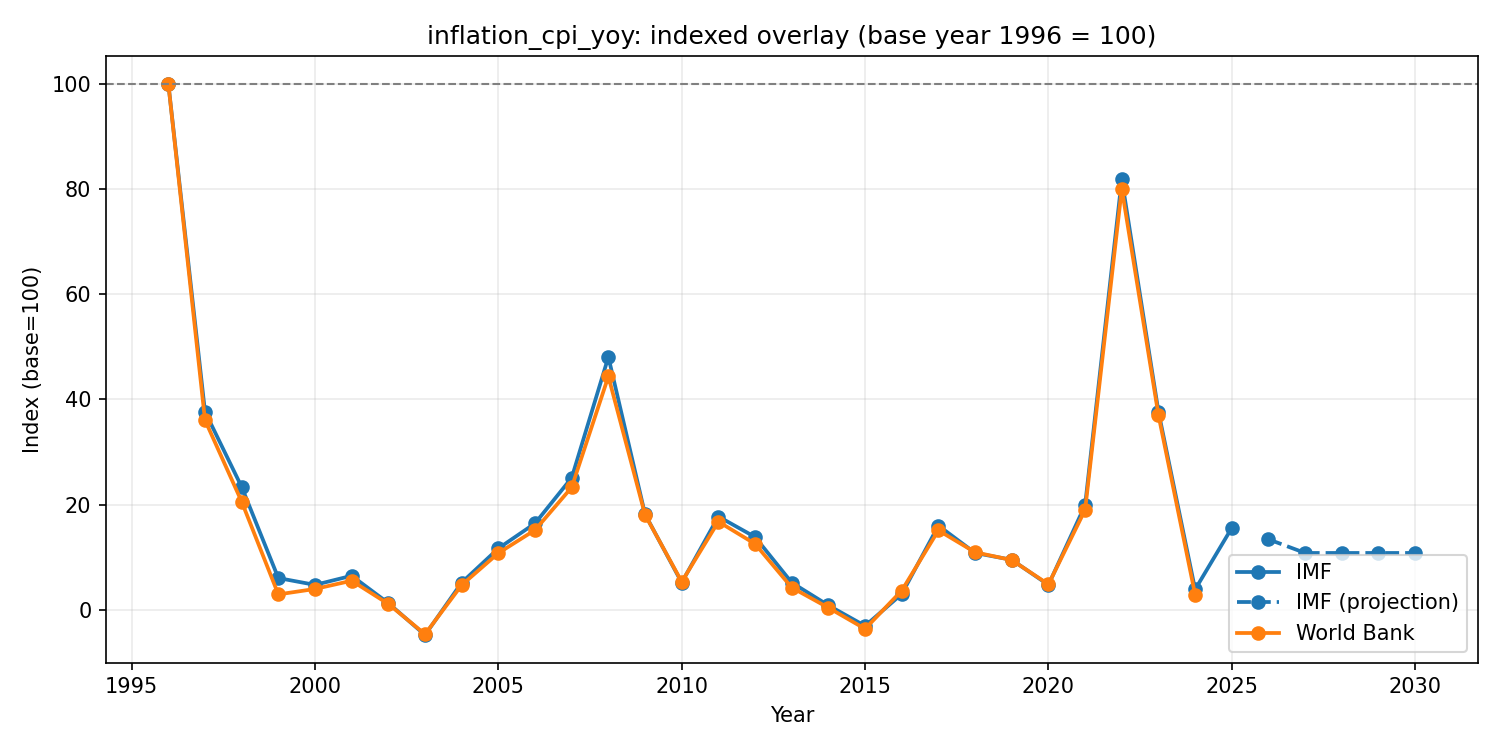

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FP.CPI.TOTL.ZG`) | percent | percent | identity | Exact mapping |
| IMF (`PCPIPCH`) | source-defined | percent | identity | Proxy-equivalent concept; future years can be projections |
| Eurostat (`prc_hicp_manr`) | `RCH_A` monthly YoY | percent annual | annual mean of monthly values | Proxy with methodology differences |

**raw**

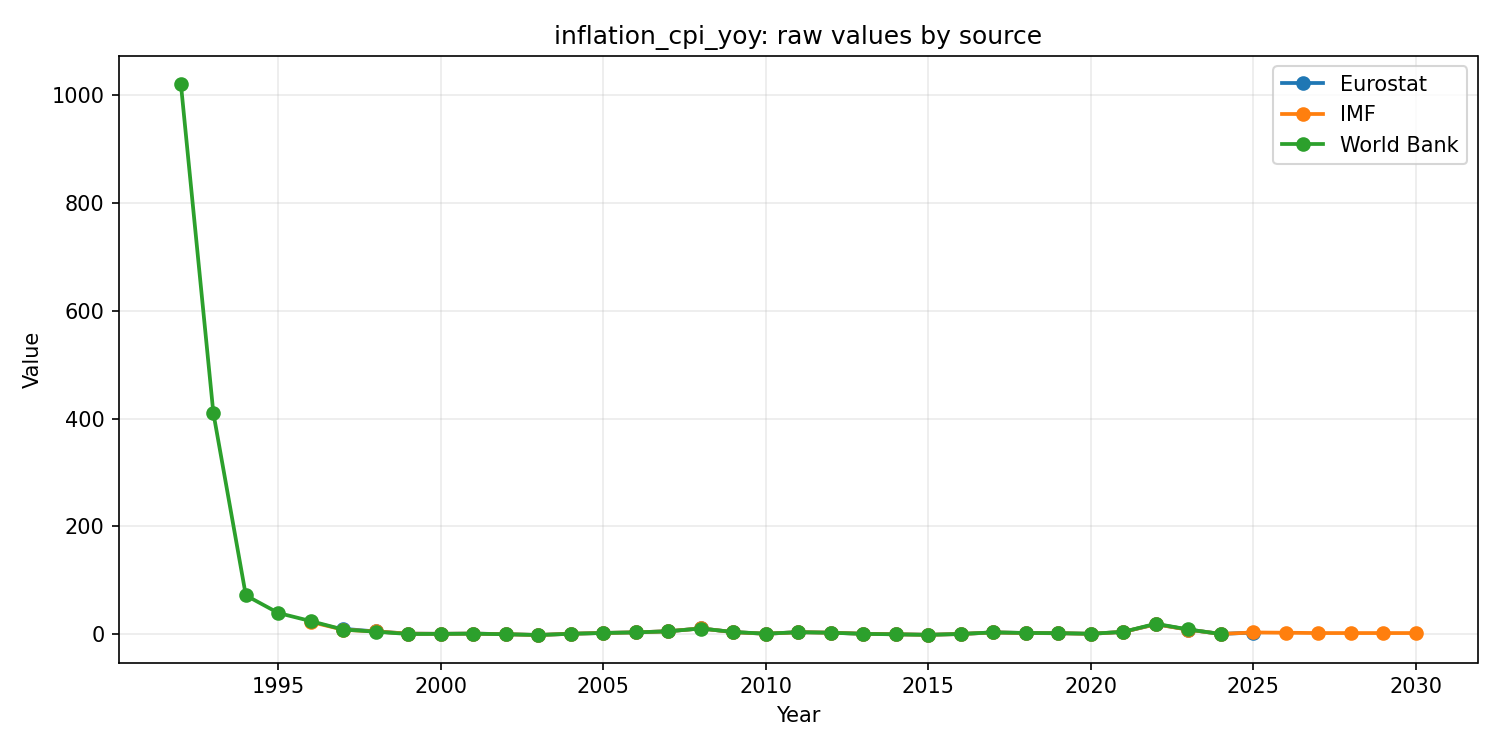

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` which is rendered in canonical USD to avoid mixed-scale flattening.

**raw_harmonized**

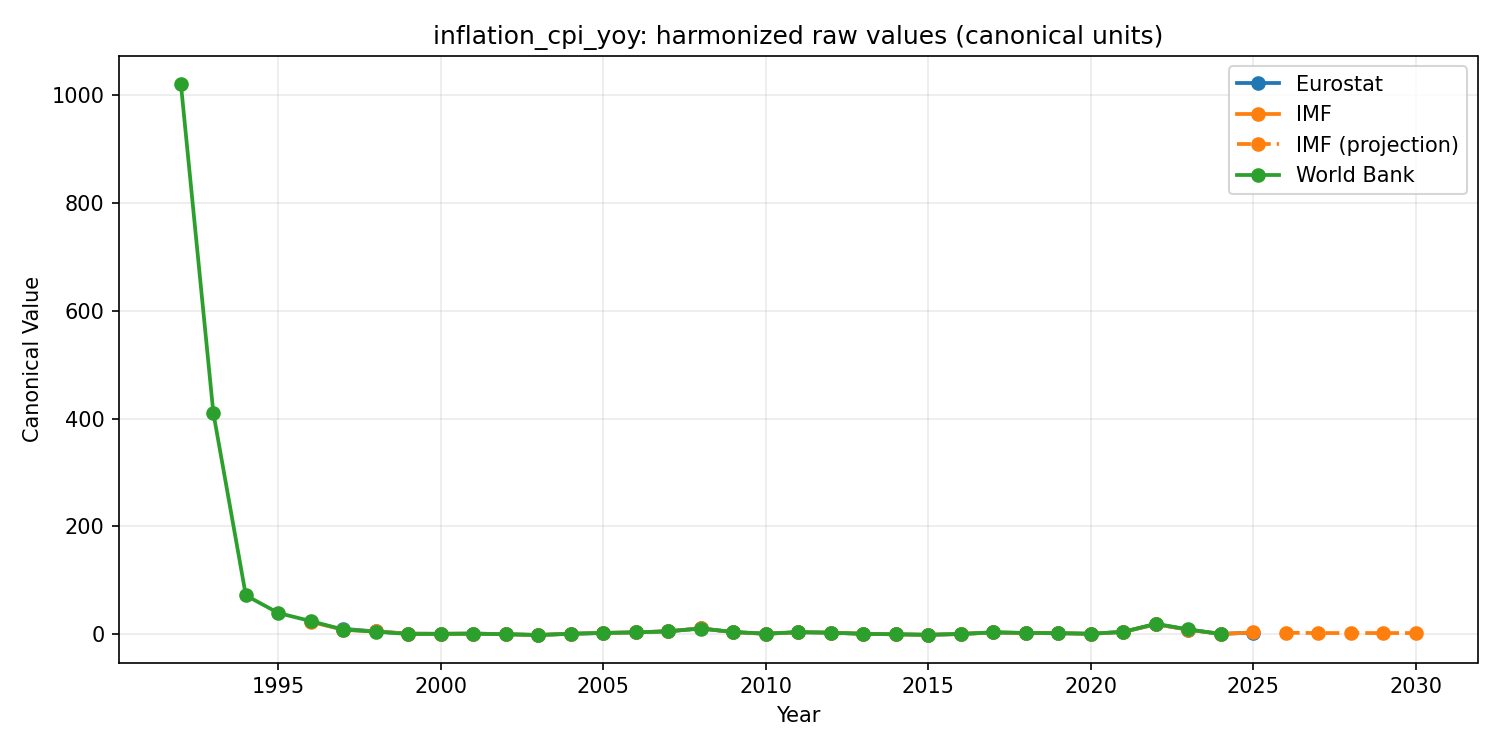

_Glossary:_ canonical-unit values for comparable cross-source analysis.

## trade_balance_pct_gdp

,chart_type,status,base_year,file_path,note
14,overlay_index,ok,1995.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
12,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
13,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


**overlay_index**

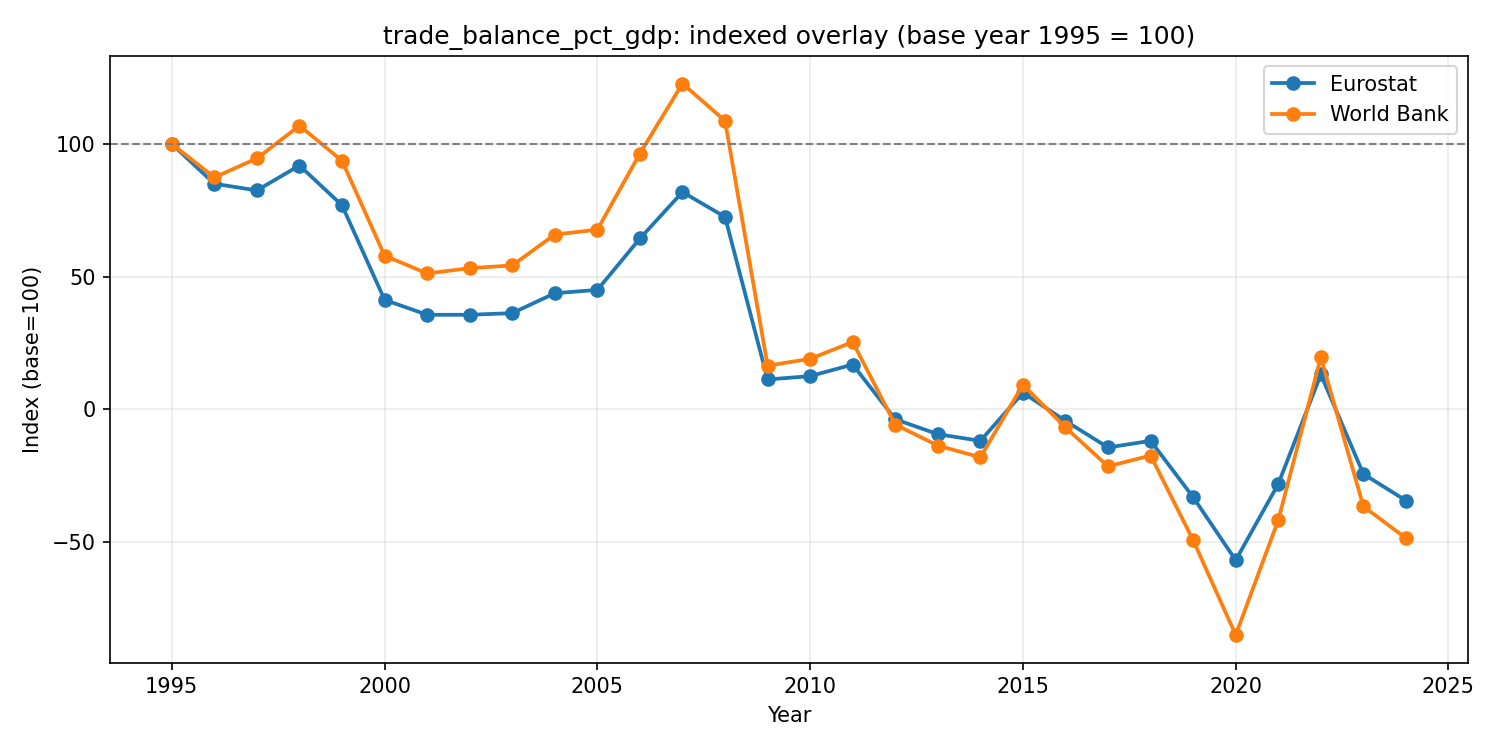

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`NE.RSB.GNFS.ZS`) | percent of GDP | percent of GDP | identity | Exact mapping |
| IMF (`BT_GDP`) | source-defined | percent of GDP | identity | Proxy with potential definition differences |
| Eurostat (`bop_gdp6_q`) | `PC_GDP` | percent of GDP | identity | Proxy (BPM6 framing differs) |

**raw**

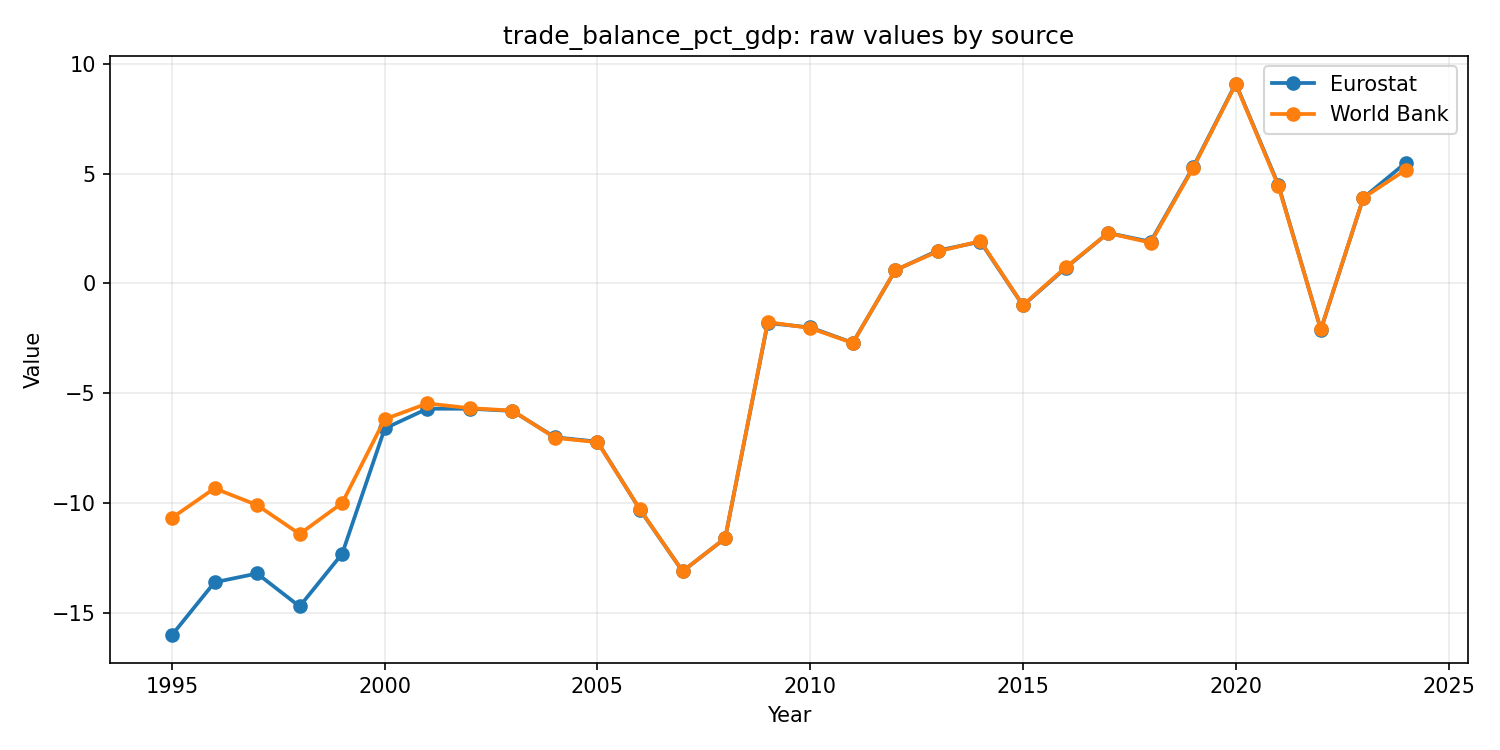

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` which is rendered in canonical USD to avoid mixed-scale flattening.

**raw_harmonized**

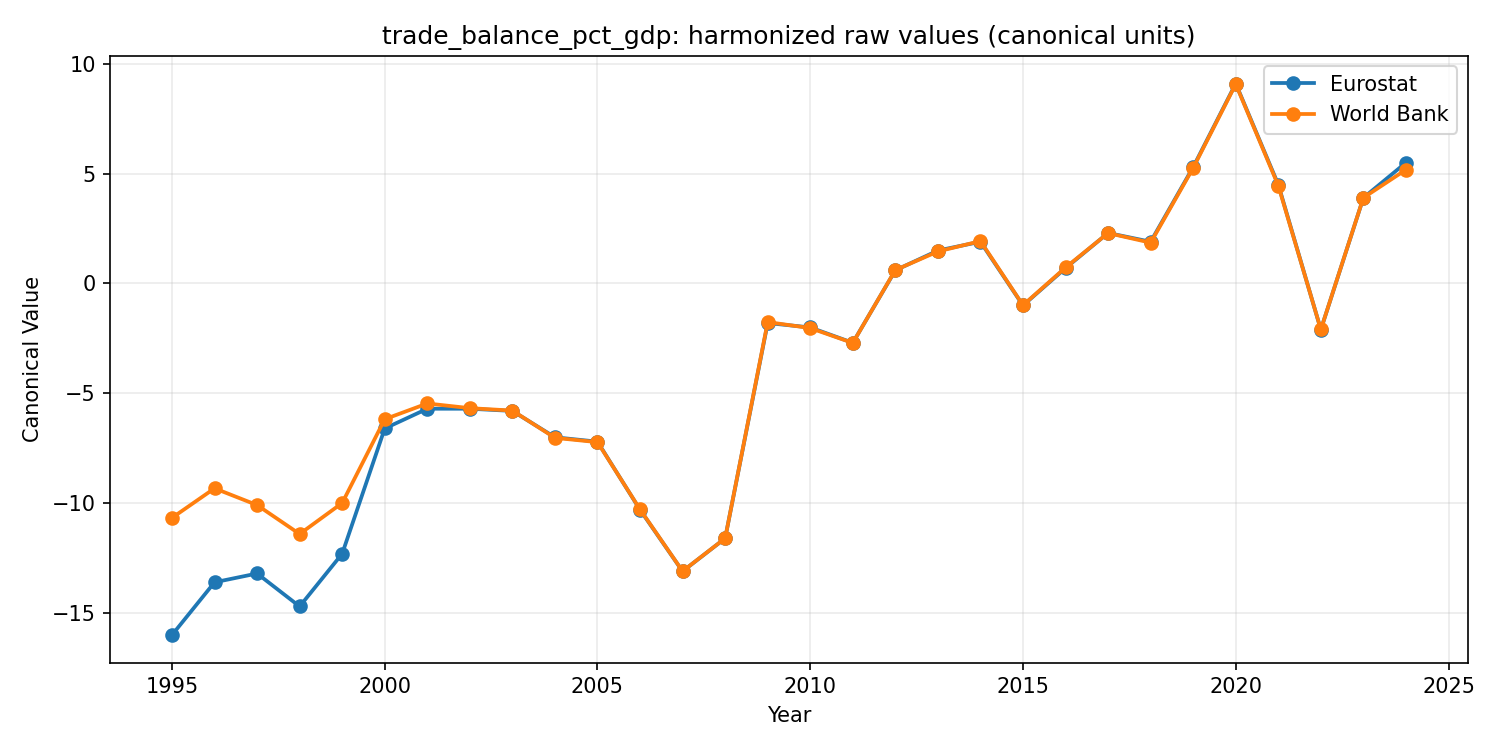

_Glossary:_ canonical-unit values for comparable cross-source analysis.

## lending_interest_rate

,chart_type,status,base_year,file_path,note
11,overlay_index,ok,2001.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
9,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
10,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


**overlay_index**

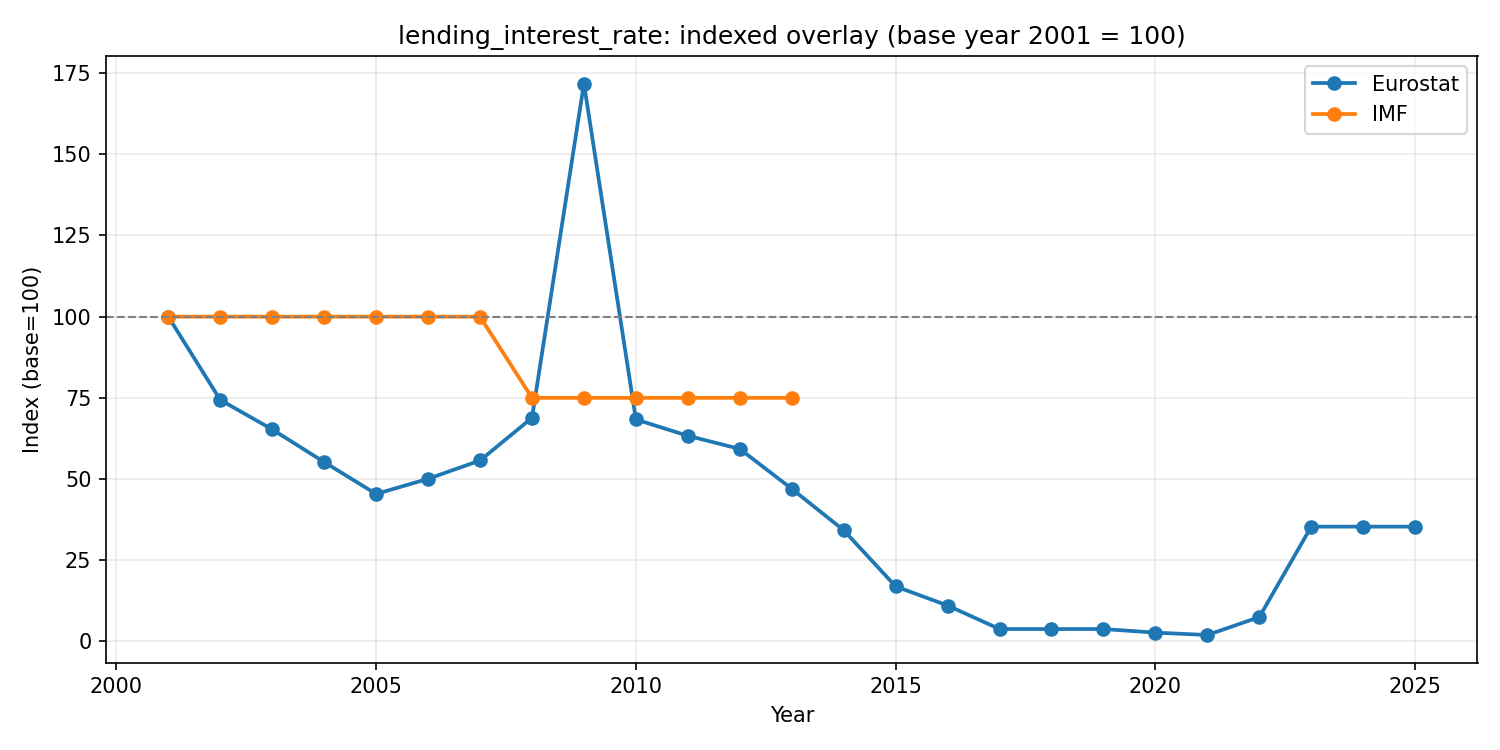

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`FR.INR.LEND`) | percent | percent | identity | Endpoint resolves but currently no numeric LT rows |
| IMF (`Ka_mm`) | index | percent (pipeline canonical target) | identity | Weak proxy; LT availability only to 2013 |
| Eurostat (`irt_lt_mcby_a`) | percent | percent | identity | Proxy (long-term rate, not direct lending rate) |

**raw**

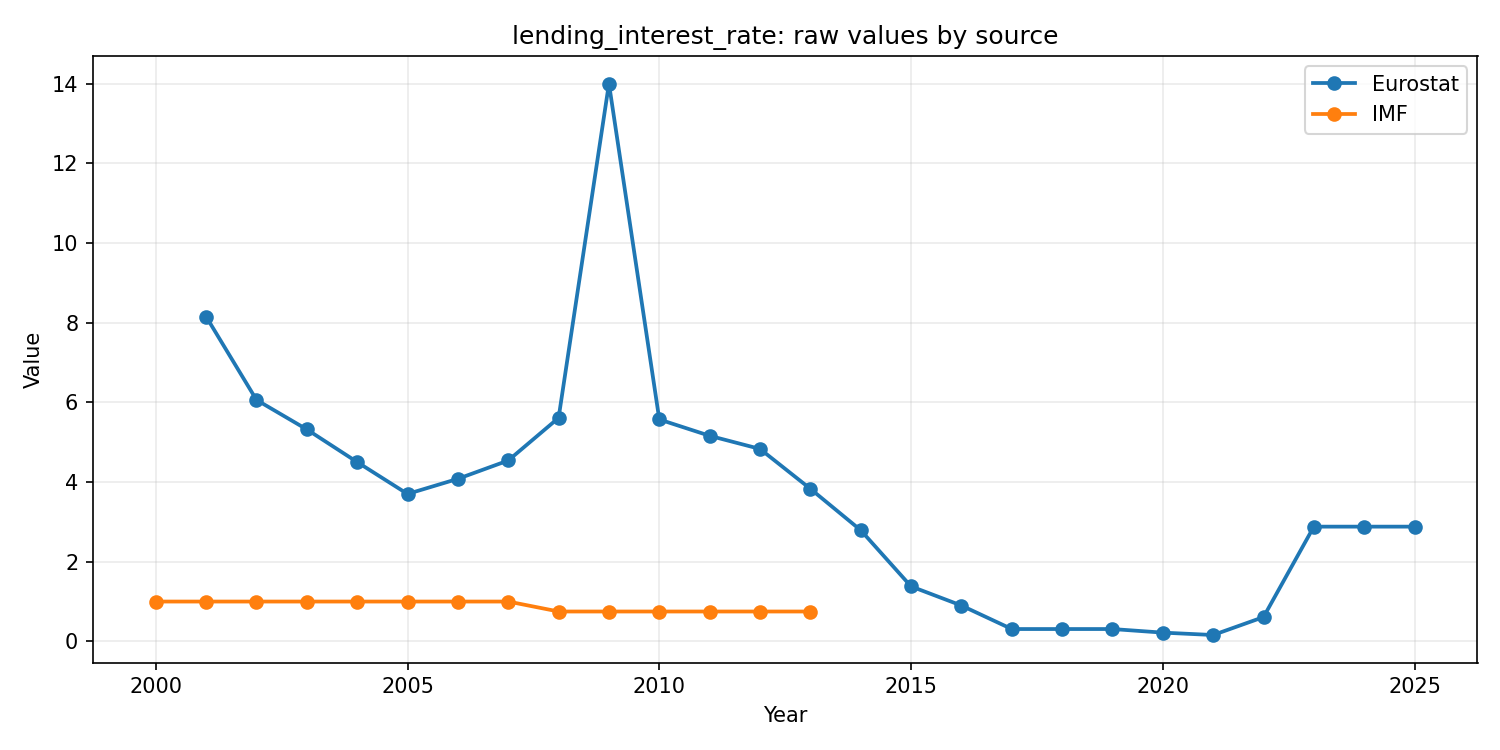

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` which is rendered in canonical USD to avoid mixed-scale flattening.

**raw_harmonized**

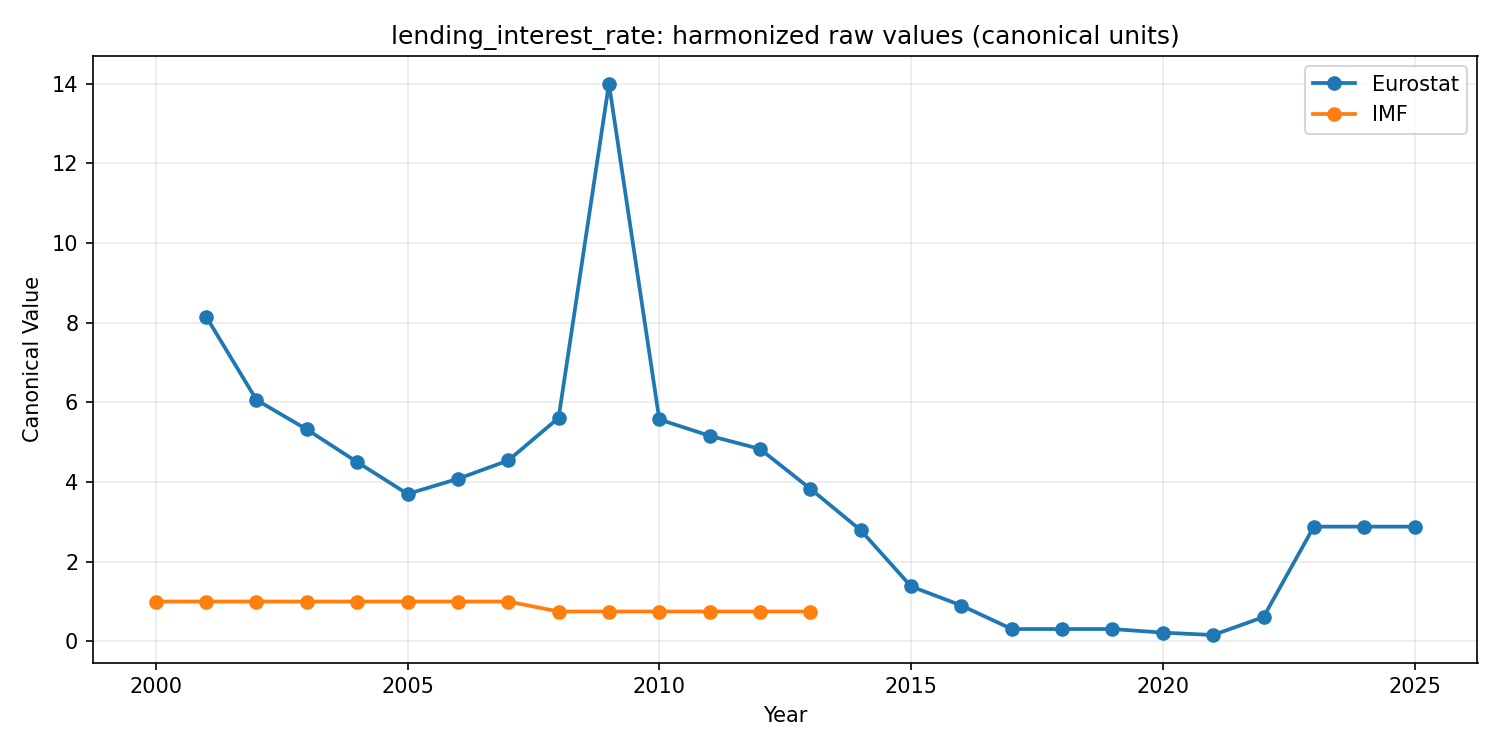

_Glossary:_ canonical-unit values for comparable cross-source analysis.

## unemployment_rate

,chart_type,status,base_year,file_path,note
17,overlay_index,ok,1999.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
15,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
16,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


**overlay_index**

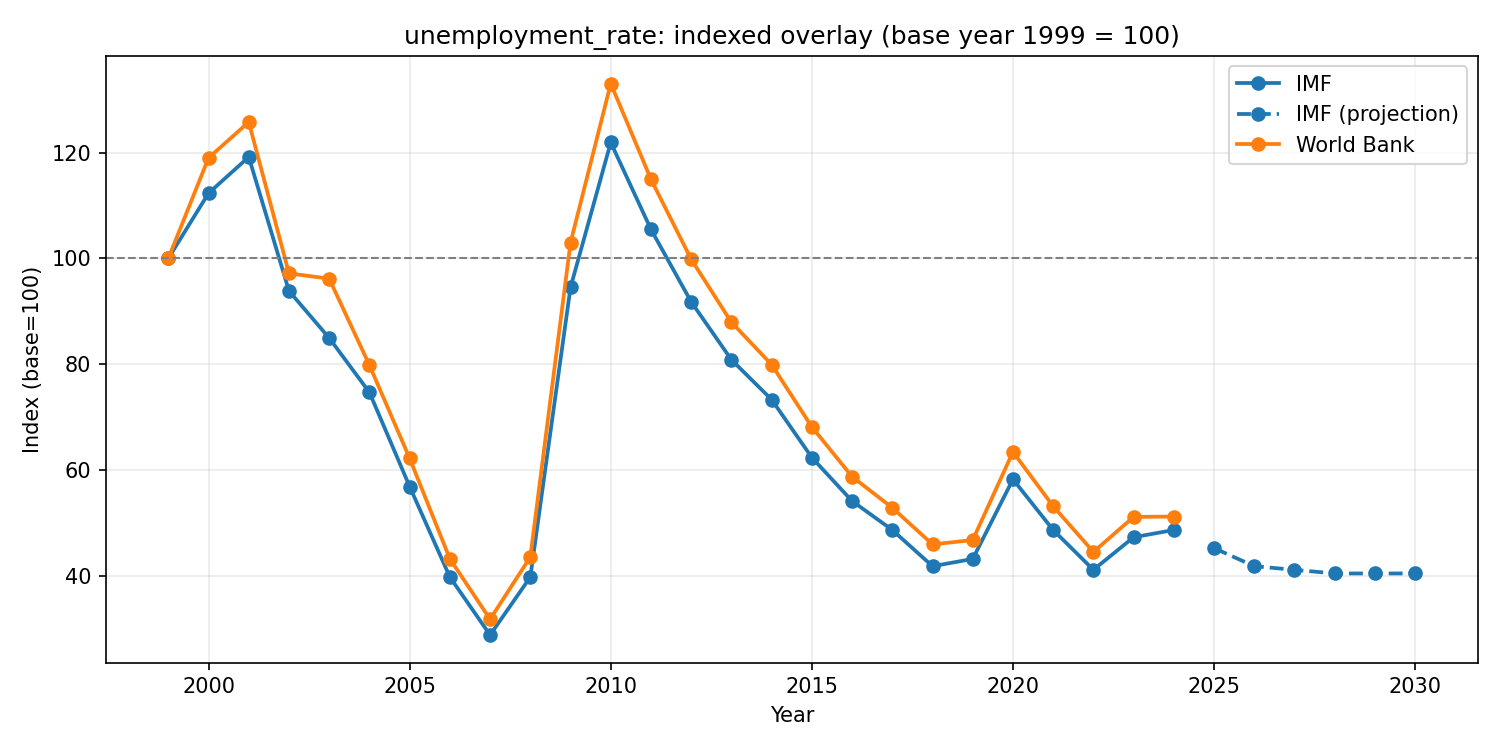

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`SL.UEM.TOTL.ZS`) | percent | percent | identity | Exact mapping |
| IMF (`LUR`) | source-defined | percent | identity | Comparable concept; possible projection years |
| Eurostat (`une_rt_a`) | `PC_ACT` | percent | identity | Proxy (methodology differences) |

**raw**

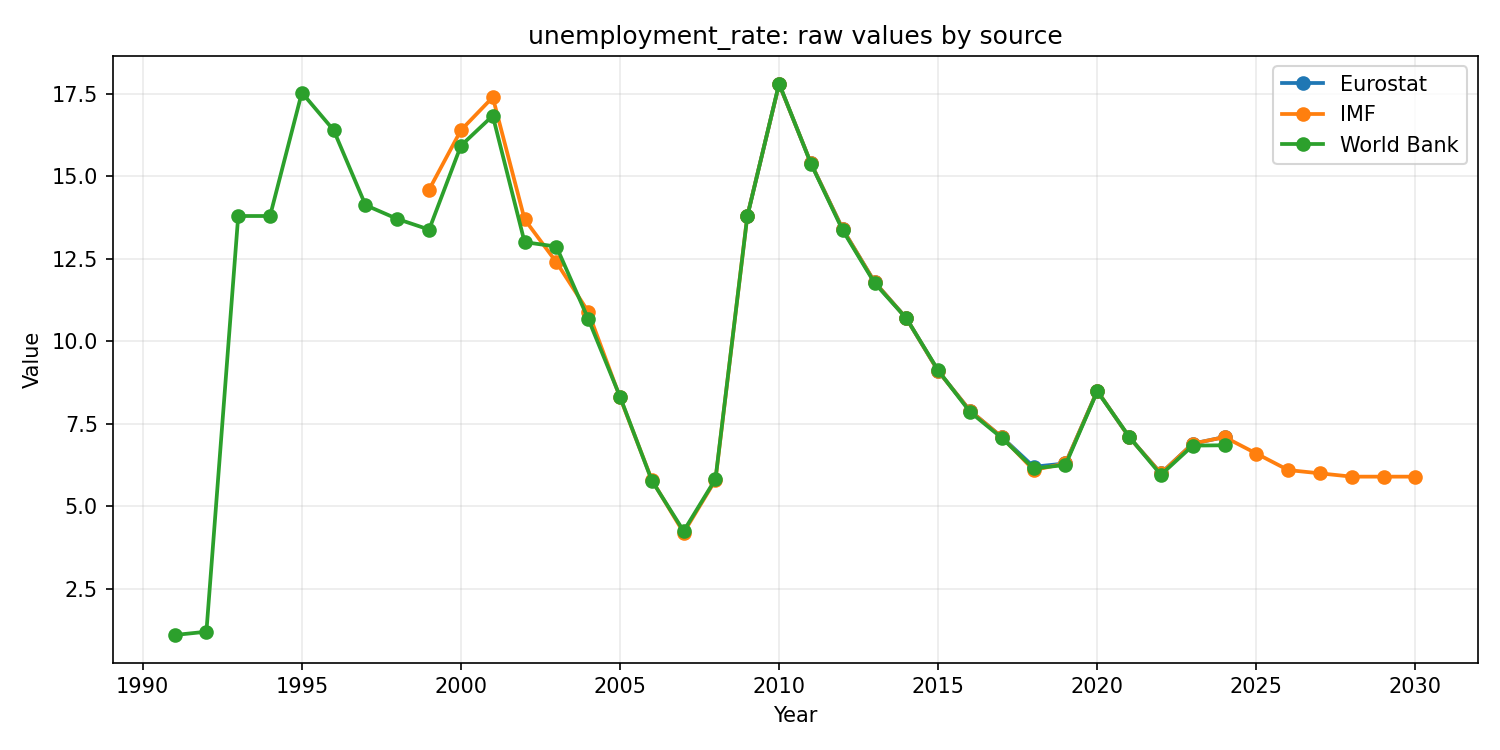

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` which is rendered in canonical USD to avoid mixed-scale flattening.

**raw_harmonized**

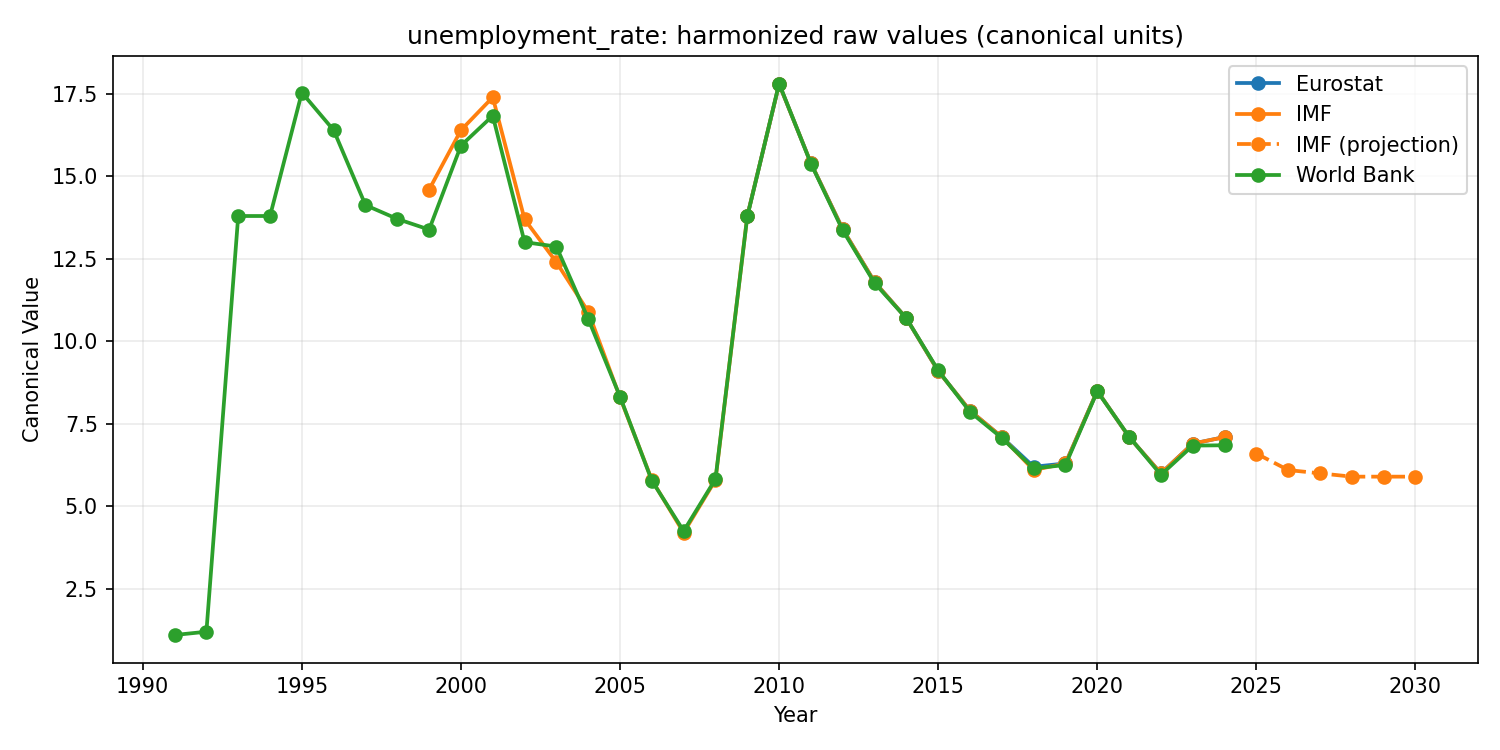

_Glossary:_ canonical-unit values for comparable cross-source analysis.

## exchange_rate_lcu_per_usd

,chart_type,status,base_year,file_path,note
2,overlay_index,ok,1994.0,/workspaces/da-ai/bs2026_student_projects/Artu...,
0,raw,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,
1,raw_harmonized,ok,NaN,/workspaces/da-ai/bs2026_student_projects/Artu...,


**overlay_index**

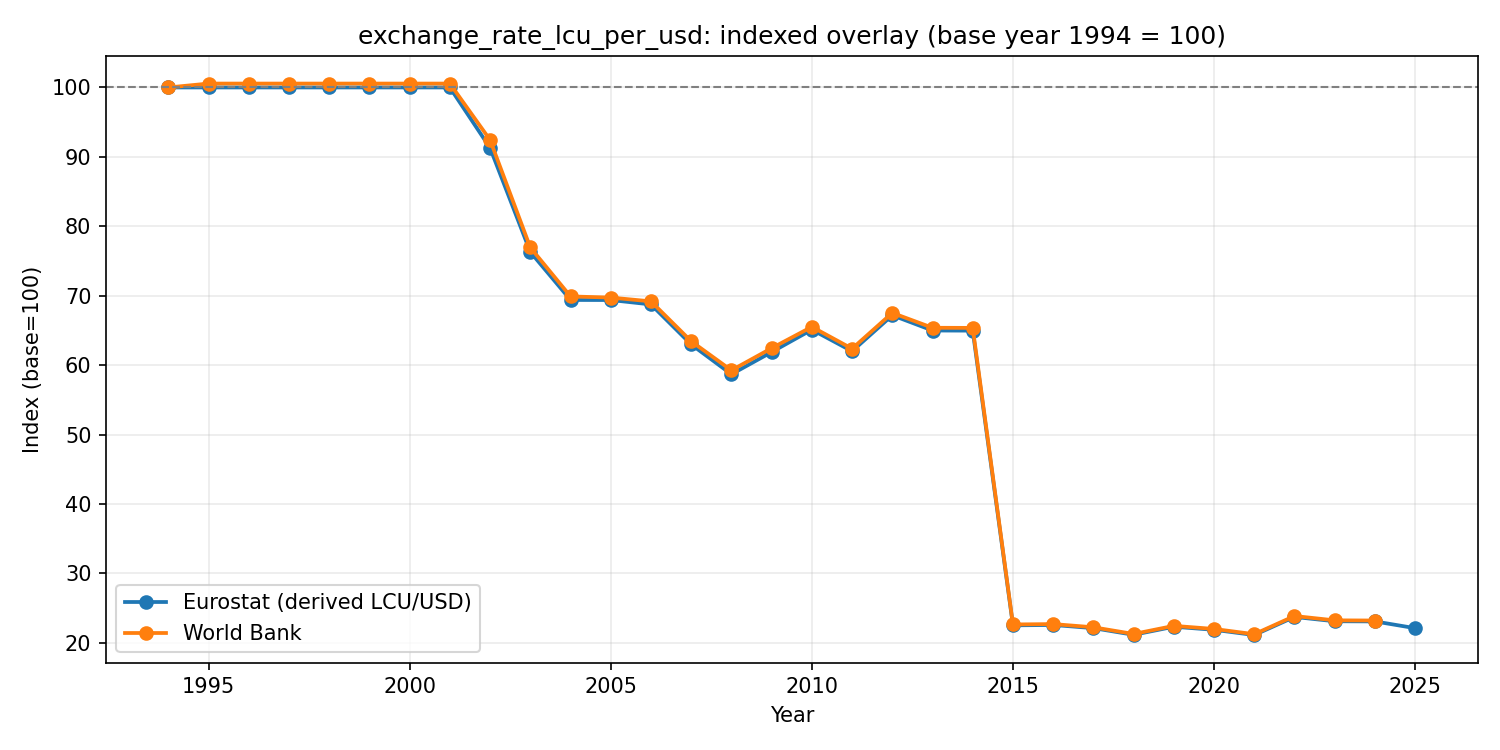

_Glossary:_ indexed comparison derived from harmonized comparable values.

**Indicator mapping glossary**

| Source | Raw Unit | Canonical Unit | Transform | Notes |
|---|---|---|---|---|
| World Bank (`PA.NUS.FCRF`) | LCU per USD | LCU per USD | identity | Exact mapping |
| Eurostat raw (`ert_bil_eur_a`) | USD per EUR (`NAC`) | LCU per USD target | not directly comparable | Marked `is_comparable=false` for cross-source overlays |
| Eurostat derived (`eurostat_derived`) | derived from USD/EUR | LCU per USD | LT regime rules by year | Comparable series used in harmonized/overlay charts |

**raw**

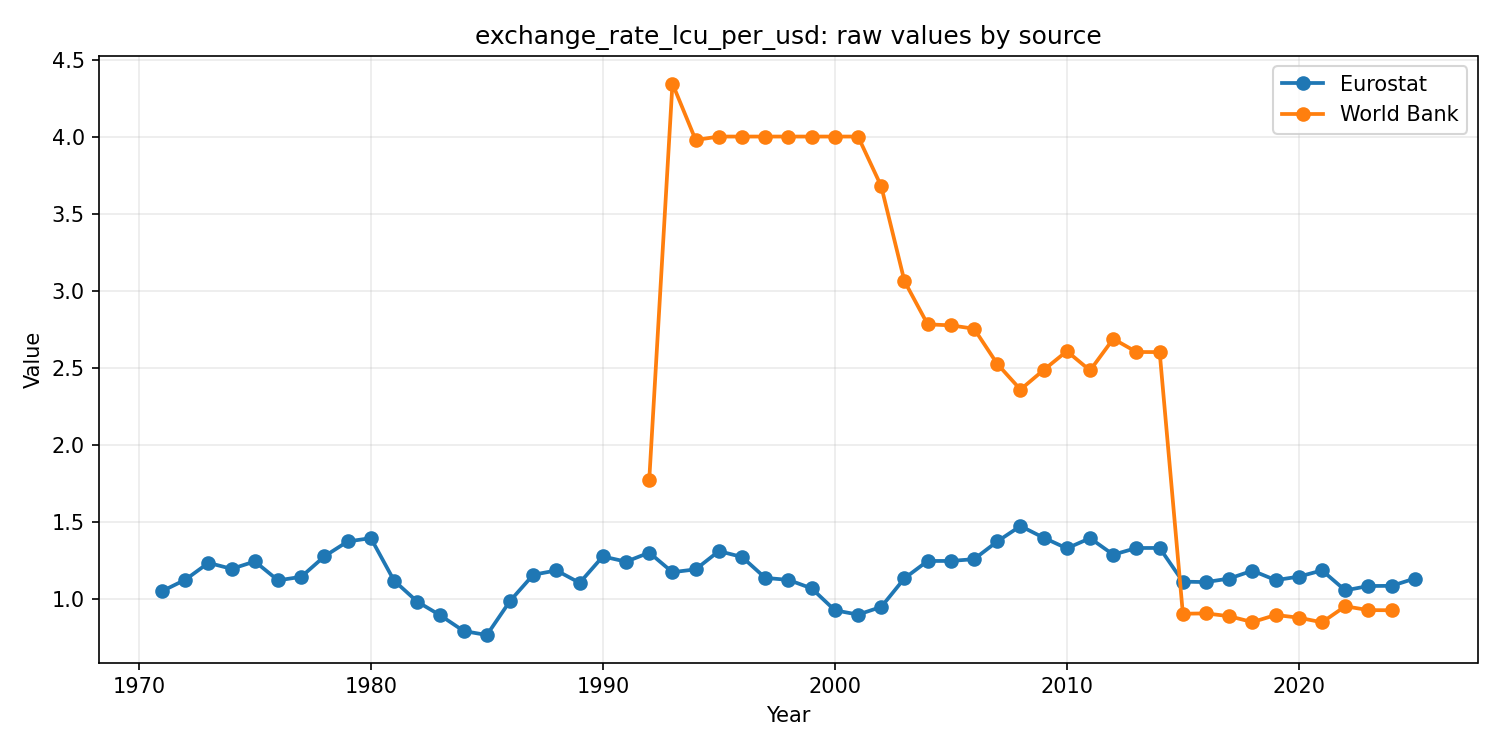

_Glossary:_ source-native values exactly as returned after normalization (not unit-harmonized), except `gdp_current_usd` which is rendered in canonical USD to avoid mixed-scale flattening.

**raw_harmonized**

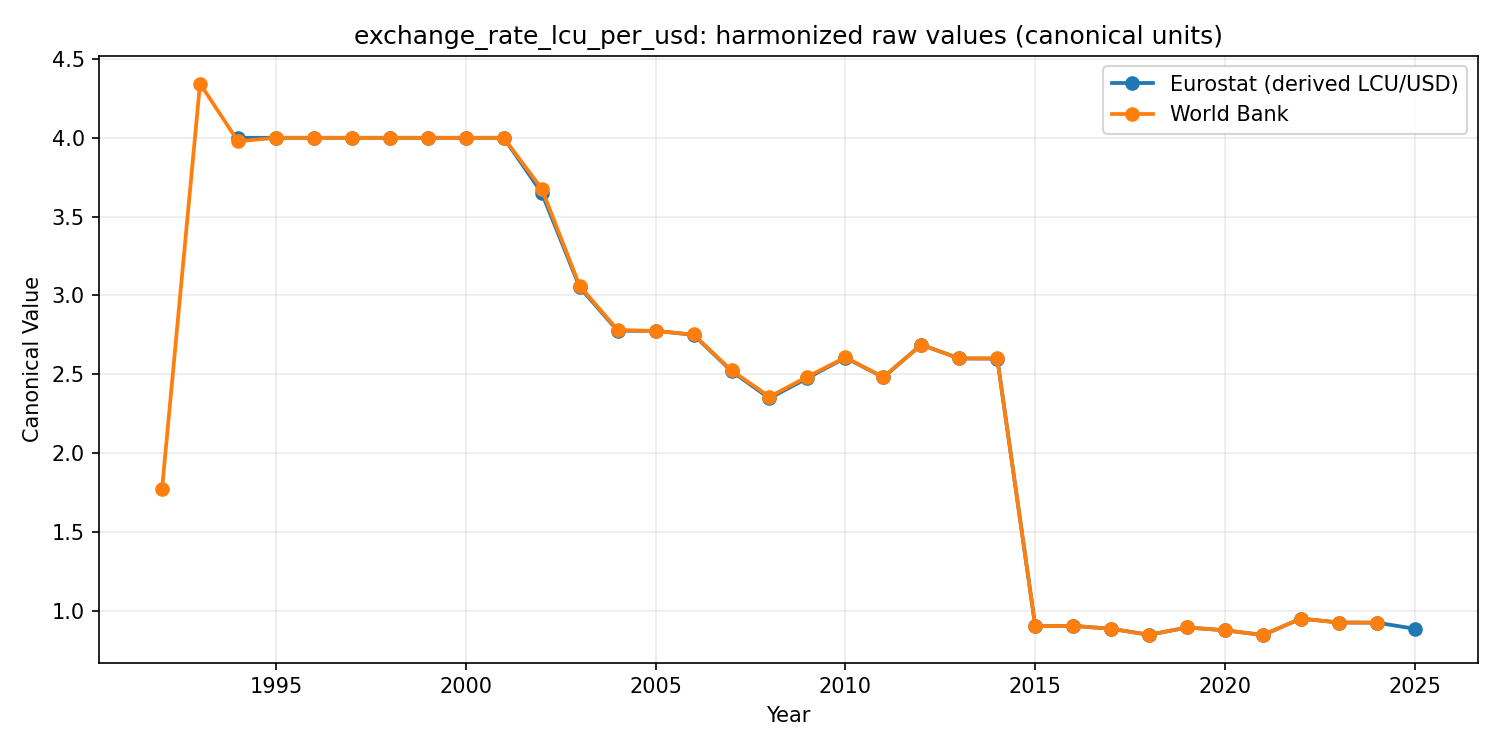

_Glossary:_ canonical-unit values for comparable cross-source analysis.

In [7]:
for indicator_id in indicator_index['indicator_id'].tolist():
    display(Markdown(f'## {indicator_id}'))
    manifest_rows = chart_manifest[chart_manifest['indicator_id'] == indicator_id].sort_values('chart_type')
    display(manifest_rows[['chart_type', 'status', 'base_year', 'file_path', 'note']])

    indicator_glossary_shown = False
    for _, chart_row in manifest_rows.iterrows():
        if chart_row['status'] != 'ok':
            continue

        chart_type = str(chart_row['chart_type'])
        display(Markdown(f"**{chart_type}**"))
        display(Image(filename=chart_row['file_path']))

        chart_note = chart_type_glossary.get(chart_type)
        if chart_note:
            display(Markdown(f"_Glossary:_ {chart_note}"))

        if not indicator_glossary_shown:
            indicator_note = indicator_glossary.get(indicator_id, '')
            if indicator_note:
                display(Markdown("**Indicator mapping glossary**\n\n" + indicator_note))
                indicator_glossary_shown = True


## Notes

- `coverage_gaps.csv` documents unresolved exact matches and all proxy mappings.
- `normalized_indicator_long.csv` is the analysis-ready long table used for plotting.
- Charts are saved under `outputs/charts/`.
